# Encuesta Clima de los Negocios

In [98]:
# =============================================================================
# 0. CONFIGURACIÓN
# =============================================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42

DATA_DIR = './datos_limpios'
corredores = pd.read_csv(f'{DATA_DIR}/ECN_unified.csv')

# Ajustamos variables

In [99]:
# Convertir situacion_economica en dummy: 1 y 2 → 0, 3 → 1
corredores['situacion_econ_empeorara'] = (corredores['situacion_economica'] == 3).astype(int)
corredores = corredores.drop(columns=['situacion_economica'])

# Convertir seguridad_aumento en dummy: 1 y 2 → 0, 3 → 1
corredores['inseguridad_aumento'] = (corredores['seguridad_aumento'] == 3).astype(int)
corredores = corredores.drop(columns=['seguridad_aumento'])

# Convertir percepcion_seguridad en dummy: 1 y 3 → 0, 2 → 1
corredores['bogota_insegura'] = (corredores['percepcion_seguridad'] == 2).astype(int)
corredores = corredores.drop(columns=['percepcion_seguridad'])

# Convertir year en dummy: 2024 → 1, 2023 → 0
corredores['anio_2024'] = (corredores['year'] == 2024).astype(int)
corredores = corredores.drop(columns=['year'])

# Eliminar variable mercado y filas donde tamano == 4
corredores = corredores.drop(columns=['mercado', 'cargo', 'victima', 'BD_MATRICULA'])
corredores = corredores[corredores['tamano'] != 4]

# Copia del df para K-Means
df_clustering = corredores.copy()

# Guardar variables categóricas para comparar con la segmentación después
meta = df_clustering[['sector_economico', 'tamano']].copy()
df_clustering = df_clustering.drop(columns=['sector_economico', 'tamano'])

# Promediar variables de distrito y nacionales para necesidades del empresario
pairs = [
    ('inv_extranjera',    'dis_inv_extranjera'),
    ('Stem',              'dis_Stem'),
    ('simp_tramites',     'dis_simp_tramites'),
    ('gob_recurso_humano','dis_recurso_humano'),
    ('func_empresas',     'dis_func_empresas'),
    ('sistema_salud',     'dis_sistema_salud'),
    ('acceso_finan',      'dis_acceso_finan'),
    ('gob_seguridad',     'dis_seguridad'),
    ('inno_emprend',      'dis_inno_emprend'),
    ('ayuda_empresas',    'dis_ayuda_empresas'),
    ('mitig_crisis_int',  'dis_mitig_crisis_int'),
    ('fintech',           'dis_fintech'),
]

for var, dis_var in pairs:
    df_clustering[var] = (df_clustering[var] + df_clustering[dis_var]) / 2
    df_clustering = df_clustering.drop(columns=[dis_var])

# Convertir denuncio en tres dummies (1=vic_denun, 2=vic_no_denun, 3=no_vic)
df_clustering['vic_denun']     = (df_clustering['denuncio'] == 1).astype(int)
df_clustering['vic_no_denun']  = (df_clustering['denuncio'] == 2).astype(int)
df_clustering['no_vic']        = (df_clustering['denuncio'] == 3).astype(int)
df_clustering = df_clustering.drop(columns=['denuncio'])

df_clustering

,impacto_internacional,entorno_inversion,capacidad_compra,crecimiento_econ,infraestructura,conectividad,facil_crear_emp,recurso_humano,estab_jurid,seguridad,promg_forta_emp,reg_mercado_lab,servicios_pub,produc_finan,facil_comex,impuestos,hurto,informatico,fraude,extorsion,estafa,hurto_maq,ataq_infraestruc,vandalismo,secuestro,...,mitig_crisis_int,fintech,inst_alarm,inst_cam_vig,letreros_disuasivos,seguridad_priv,refor_puer_ven,art_autoridades,cap_per_estrg_prev,ninguna,perd_clientes,perd_produc_trab,daños_establ,imp_salud_fis_mental,desin_inver,daño_reputacional,pago_seg_priv,no_gen_cost,situacion_econ_empeorara,inseguridad_aumento,bogota_insegura,anio_2024,vic_denun,vic_no_denun,no_vic
0,5,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
1,3,3,2,3,3,3,1,3,3,3,2,3,3,2,2,2,0,0,0,0,0,0,0,0,0,...,0.5,0.0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,0,0,0,1
2,3,4,4,4,4,4,4,5,4,4,5,4,4,3,4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.5,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
3,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,...,0.5,0.0,1,1,1,0,1,0,0,0,1,1,0,0,1,1,0,0,0,1,0,0,1,0,0
5,3,3,3,3,3,3,2,2,3,2,2,3,2,3,2,2,0,0,0,0,0,0,0,0,0,...,0.0,0.5,1,1,1,1,1,1,1,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4243,2,1,2,1,2,3,2,4,1,1,2,1,4,4,2,1,1,0,0,0,0,0,0,0,0,...,0.0,0.0,1,1,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0
4244,2,3,1,1,5,5,5,5,5,1,5,1,5,3,3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0,1
4245,2,3,3,3,1,5,5,5,3,3,3,3,5,5,4,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0,1,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,1,0,1,0,0,1
4246,4,4,5,3,1,3,5,3,3,1,3,3,3,3,3,4,0,0,0,0,0,0,0,0,0,...,0.5,0.0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1


# PCA

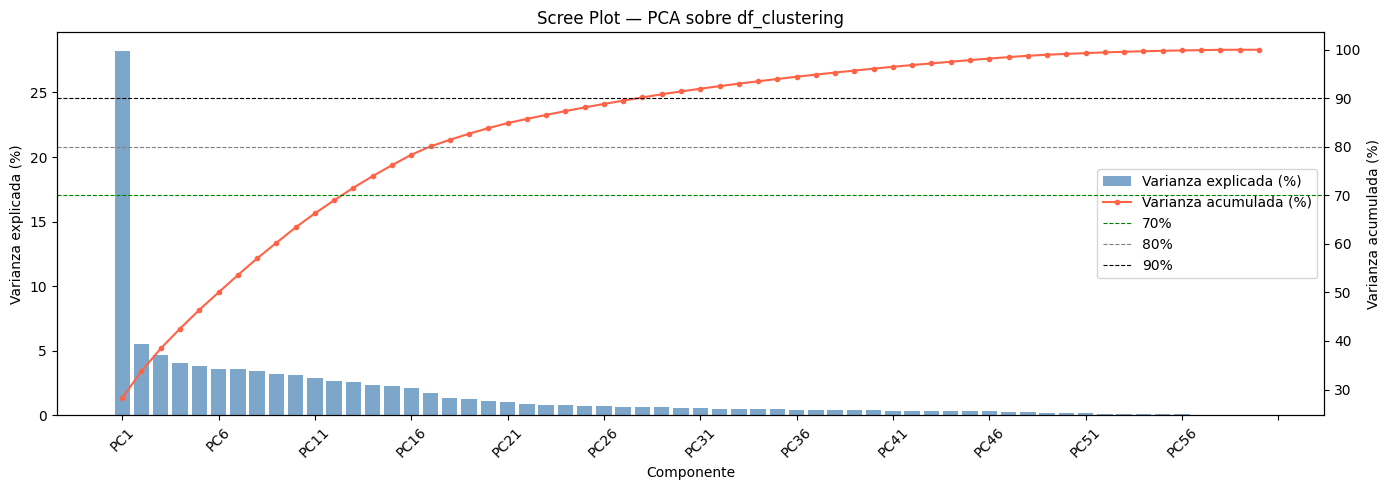

Componentes para 70% de varianza: 13
Componentes para 80% de varianza: 17
Componentes para 90% de varianza: 28


In [100]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# PCA con todas las componentes
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(df_clustering)

var_exp    = pca_full.explained_variance_ratio_
cum_var    = np.cumsum(var_exp)
comp_labels = [f"PC{i+1}" for i in range(len(var_exp))]

# Scree plot
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(comp_labels, var_exp * 100, color='steelblue', alpha=0.7, label='Varianza explicada (%)')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_xlabel('Componente')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(comp_labels, cum_var * 100, color='tomato', marker='o', markersize=3, label='Varianza acumulada (%)')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.axhline(70, color='green',  linestyle='--', linewidth=0.8, label='70%')
ax2.axhline(80, color='gray',   linestyle='--', linewidth=0.8, label='80%')
ax2.axhline(90, color='black',  linestyle='--', linewidth=0.8, label='90%')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Scree Plot — PCA sobre df_clustering')
plt.tight_layout()
plt.show()

# Número de componentes para 70%, 80% y 90% de varianza
n_70 = int(np.argmax(cum_var >= 0.70)) + 1
n_80 = int(np.argmax(cum_var >= 0.80)) + 1
n_90 = int(np.argmax(cum_var >= 0.90)) + 1
print(f"Componentes para 70% de varianza: {n_70}")
print(f"Componentes para 80% de varianza: {n_80}")
print(f"Componentes para 90% de varianza: {n_90}")

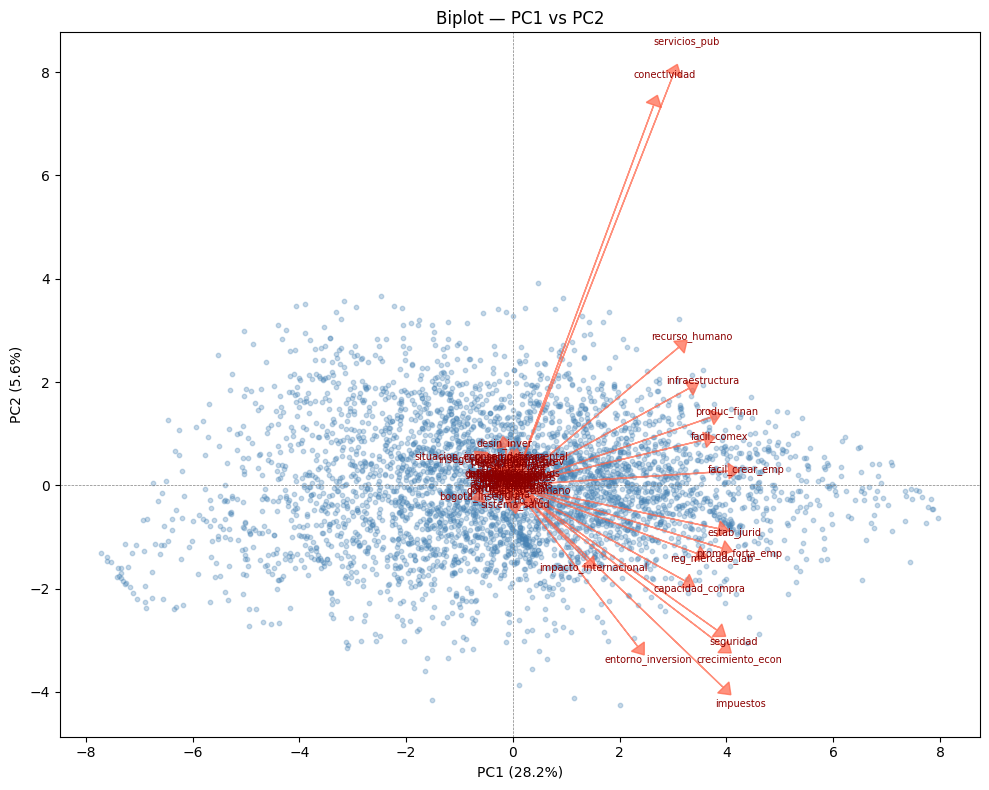

In [101]:
# Biplot PC1 vs PC2
scores      = pca_full.transform(df_clustering)
loadings    = pca_full.components_[:2].T   # shape (n_vars, 2)
feature_names = df_clustering.columns.tolist()

# Escalar scores para que quepan con las flechas
scale = np.max(np.abs(scores[:, :2])) / np.max(np.abs(loadings))

fig, ax = plt.subplots(figsize=(10, 8))

# Puntos
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=10, color='steelblue')

# Flechas (loadings)
for i, var in enumerate(feature_names):
    ax.arrow(0, 0,
             loadings[i, 0] * scale, loadings[i, 1] * scale,
             head_width=0.3, head_length=0.2,
             fc='tomato', ec='tomato', alpha=0.7)
    ax.text(loadings[i, 0] * scale * 1.08,
            loadings[i, 1] * scale * 1.08,
            var, fontsize=7, ha='center', va='center', color='darkred')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Biplot — PC1 vs PC2')
plt.tight_layout()
plt.show()

In [102]:
# Loadings PC1 y PC2
loadings_df = pd.DataFrame(
    pca_full.components_[:2].T,
    index=df_clustering.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1', key=abs, ascending=False)

print(loadings_df.to_string())

                               PC1       PC2
facil_crear_emp           0.295870  0.020056
impuestos                 0.288658 -0.286845
crecimiento_econ          0.288131 -0.228750
promg_forta_emp           0.287333 -0.089255
estab_jurid               0.281953 -0.061499
seguridad                 0.280111 -0.205666
produc_finan              0.271877  0.096519
facil_comex               0.262982  0.064577
reg_mercado_lab           0.252848 -0.096871
infraestructura           0.241653  0.137594
capacidad_compra          0.236471 -0.135841
recurso_humano            0.227819  0.195998
servicios_pub             0.220364  0.583471
conectividad              0.193256  0.539489
entorno_inversion         0.171398 -0.228944
impacto_internacional     0.102760 -0.107747
situacion_econ_empeorara -0.041925  0.038354
bogota_insegura          -0.041860 -0.014467
inseguridad_aumento      -0.028255  0.033656
no_vic                    0.019678 -0.019734
hurto                    -0.018442  0.015997
gob_seguri

# K-Means

In [103]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Espacio PCA reducido al 70% de varianza explicada
X_pca = scores[:, :n_70]

# ── Selección de k sobre espacio PCA ─────────────────────────────────────────
K_RANGE = range(2, 13)
results = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    results.append({
        "k":                 k,
        "inertia":           km.inertia_,
        "silhouette":        silhouette_score(X_pca, labels, sample_size=500, random_state=RANDOM_STATE),
        "davies_bouldin":    davies_bouldin_score(X_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
    })

res = pd.DataFrame(results)
print(res.round(4).to_string(index=False))

# ── K óptimo por Silhouette (mayor = mejor separación) ───────────────────────
k_opt = int(res.loc[res["silhouette"].idxmax(), "k"])
print(f"\nK óptimo (Silhouette máximo): k = {k_opt}"
      f"  →  sil = {res['silhouette'].max():.4f}"
      f"  |  db = {res.loc[res['silhouette'].idxmax(), 'davies_bouldin']:.4f}"
      f"  |  ch = {res.loc[res['silhouette'].idxmax(), 'calinski_harabasz']:.1f}")

 k    inertia  silhouette  davies_bouldin  calinski_harabasz
 2 53814.5859      0.2016          1.6848          1358.7119
 3 48625.8608      0.1318          2.0117           976.1223
 4 46359.6201      0.0966          2.4631           750.9338
 5 44612.2811      0.0914          2.4608           626.2967
 6 43366.5446      0.0907          2.4323           539.4614
 7 42342.3658      0.0796          2.5488           477.2600
 8 41496.1260      0.0578          2.4953           429.5613
 9 40696.0263      0.0608          2.4536           393.4892
10 39997.7476      0.0586          2.5049           363.9393
11 39404.8027      0.0586          2.4435           338.7107
12 38860.6638      0.0592          2.4127           317.4998

K óptimo (Silhouette máximo): k = 2  →  sil = 0.2016  |  db = 1.6848  |  ch = 1358.7


In [104]:
from sklearn.metrics import silhouette_samples

def evaluate_clustering(X, labels, method_name):
    """Calcula métricas de clustering y retorna un dict resumen."""
    n_clusters = len(set(labels) - {-1})
    n_noise    = (labels == -1).sum()
    mask       = labels != -1
    if n_clusters >= 2 and mask.sum() > n_clusters:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan
    return {
        "method":     method_name,
        "n_clusters": n_clusters,
        "n_noise":    int(n_noise),
        "silhouette": round(float(sil), 4) if not np.isnan(sil) else np.nan,
    }

# Modelo K-Means final con k_opt
km_final  = KMeans(n_clusters=k_opt, n_init=20, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_pca)
res_km    = evaluate_clustering(X_pca, labels_km, f"K-Means (k={k_opt})")
print(res_km)

{'method': 'K-Means (k=2)', 'n_clusters': 2, 'n_noise': 0, 'silhouette': 0.2031}
